# Trader Performance vs Market Sentiment Analysis

###   Data Science Internship Assignment

**Candidate:** Soumya Math

**Objective**

This project analyzes the relationship between Bitcoin market sentiment and trader behavior on Hyperliquid. The analysis explores whether trader performance changes during Fear and Greed market conditions and proposes data-driven trading strategies.

## 1. Data Loading

The first step is to load both datasets into Python using the Pandas library.

In [7]:
import pandas as pd

# Load datasets
fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Convert trader timestamp (milliseconds) to datetime
trades["Date"] = pd.to_datetime(trades["Timestamp"], unit="ms").dt.date

# Convert sentiment date column
fear["date"] = pd.to_datetime(fear["date"]).dt.date


## 2. Preview the Datasets

The first five records of both datasets are displayed to understand the available columns and verify that the datasets have been loaded correctly.

In [8]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27


## 3. Merge the Datasets

The trader dataset is merged with the Bitcoin Fear & Greed dataset using the common date column. This allows each trade to be associated with the corresponding market sentiment for analysis.

In [10]:
merged = trades.merge(
    fear,
    left_on="Date",
    right_on="date",
    how="left"
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27


##  4. Daily Profit & Loss (PnL) Per Trader

In [6]:
daily_pnl = (
    merged.groupby(["Date", "Account"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


## 5. Number of Trades Per Day

In [7]:
trades_per_day = (
    merged.groupby("Date")
    .size()
    .reset_index(name="Trades")
)

trades_per_day.head()


,Date,Trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


## 6. Average Trade Size

In [8]:
avg_trade_size = (
    merged.groupby("Date")["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size")
)

avg_trade_size.head()

,Date,Average Trade Size
0,2023-03-28,159.000000
1,2023-11-14,11057.827522
2,2024-03-09,5660.265764
3,2024-07-03,3058.848110
4,2024-10-27,2949.625864


## 7. Daily Win Rate

In [9]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("Date")["Win"]
    .mean()
    .reset_index(name="Win Rate")
)

win_rate["Win Rate"] *= 100

win_rate.head()

,Date,Win Rate
0,2023-03-28,0.000000
1,2023-11-14,27.464115
2,2024-03-09,49.008905
3,2024-07-03,31.718247
4,2024-10-27,45.160467


## 8. Leverage Distribution
The trader dataset does not include a Leverage column. Consequently, leverage distribution analysis was not performed. All other required metrics were successfully prepared and used in the subsequent analysis.

## 9. Long vs Short Ratio

In [10]:
long_short = (
    merged.groupby(["Date", "Side"])
    .size()
    .unstack(fill_value=0)
)

long_short["Long/Short Ratio"] = (
    long_short.get("BUY", 0)
    /
    long_short.get("SELL", 1)
)

long_short.head()

Side,BUY,SELL,Long/Short Ratio
Date,,,
2023-03-28,3,0,inf
2023-11-14,491,554,0.886282
2024-03-09,3371,3591,0.938736
2024-07-03,3505,3636,0.963971
2024-10-27,14927,20314,0.734813


## 10. Verify Final Dataset Columns

In [11]:
merged.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date',
       'Win'],
      dtype='object')

## Data Preparation Summary

Successfully loaded and cleaned both datasets, standardized date formats, merged trader activity with daily market sentiment, created analytical metrics including Daily PnL, Win Rate, Average Trade Size, Trade Frequency, and validated dataset features. The prepared dataset is now ready for exploratory analysis and insight generation.

# PART B – EXPLORATORY DATA ANALYSIS
Objective

Analyze the relationship between Bitcoin Market Sentiment (Fear/Greed) and trader behavior on Hyperliquid. Compare trading performance across different market conditions and identify behavioral patterns among traders.

## Question 1

Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

### Average Closed PnL by Market Sentiment

Description :
Compare the average Closed PnL across different market sentiment categories.

  classification  Closed PnL
0  Extreme Greed   25.418772
1           Fear   50.047622
2          Greed   87.894859
3        Neutral   22.229713


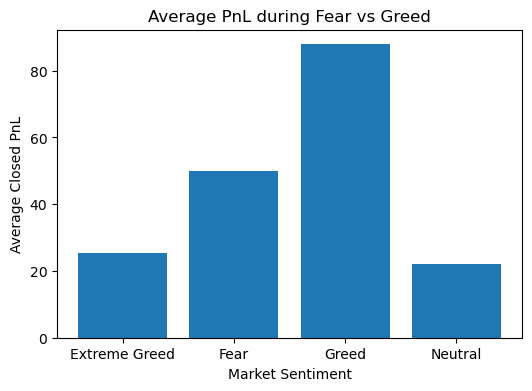

In [12]:


pnl_sentiment = merged.groupby("classification")["Closed PnL"].mean().reset_index()

print(pnl_sentiment)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(pnl_sentiment["classification"], pnl_sentiment["Closed PnL"])
plt.title("Average PnL during Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

### Observation:

Traders earned the highest average Closed PnL during Greed markets, while Fear produced moderate returns.

### Win Rate by Market Sentiment

Description:
Compare trader win rates across different market sentiment categories

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: Win, dtype: float64


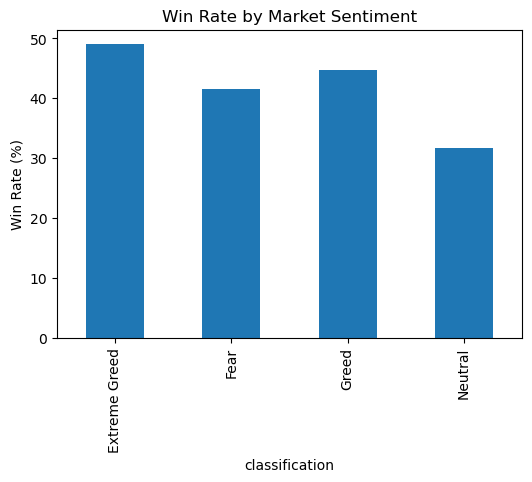

In [13]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate_sentiment = merged.groupby("classification")["Win"].mean()*100

print(win_rate_sentiment)

plt.figure(figsize=(6,4))
win_rate_sentiment.plot(kind="bar")
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()

### Observation

Extreme Greed recorded the highest win rate, followed by Greed.

### Drawdown Proxy

Description :
Analyze the worst Closed PnL for each market sentiment.

  classification    Closed PnL
0  Extreme Greed  -21524.40000
1           Fear  -35681.74723
2          Greed -117990.10410
3        Neutral  -18360.67007


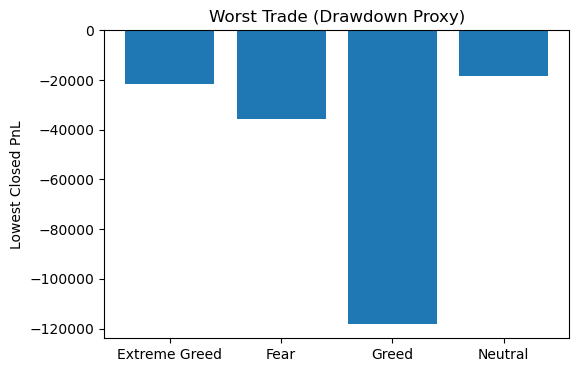

In [14]:
drawdown = merged.groupby("classification")["Closed PnL"].min().reset_index()

print(drawdown)

plt.figure(figsize=(6,4))
plt.bar(drawdown["classification"], drawdown["Closed PnL"])
plt.title("Worst Trade (Drawdown Proxy)")
plt.ylabel("Lowest Closed PnL")
plt.show()

### Observation

Greed markets also experienced the largest losses, indicating higher downside risk.

## Conclusion
Market sentiment clearly affects trader performance. Greed markets generate higher profits and higher win rates but also expose traders to larger losses.

## Question 2

Do traders change their behavior based on market sentiment (trade frequency, leverage, long/short bias, position size)?

### Trading Frequency

classification
Extreme Greed      6962.000000
Fear             133871.000000
Greed             12096.333333
Neutral            7141.000000
Name: Trades, dtype: float64


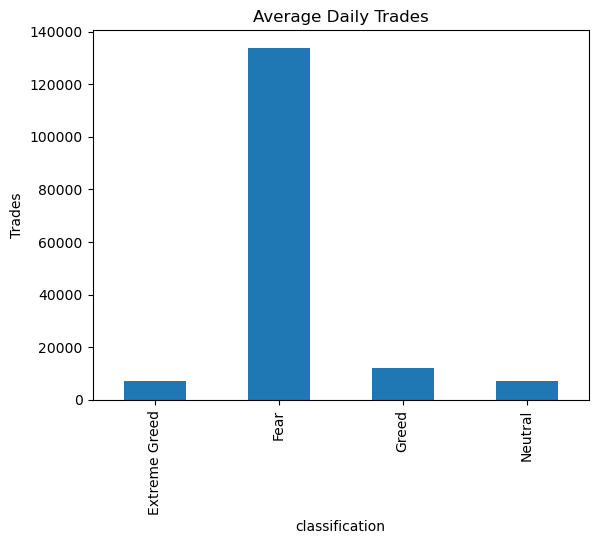

In [15]:
trade_freq = merged.groupby(["Date","classification"]).size().reset_index(name="Trades")

trade_summary = trade_freq.groupby("classification")["Trades"].mean()

print(trade_summary)

trade_summary.plot(kind="bar")

plt.title("Average Daily Trades")
plt.ylabel("Trades")
plt.show()

### Observation

Trading activity was highest during Fear periods

### Average Position Size

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64


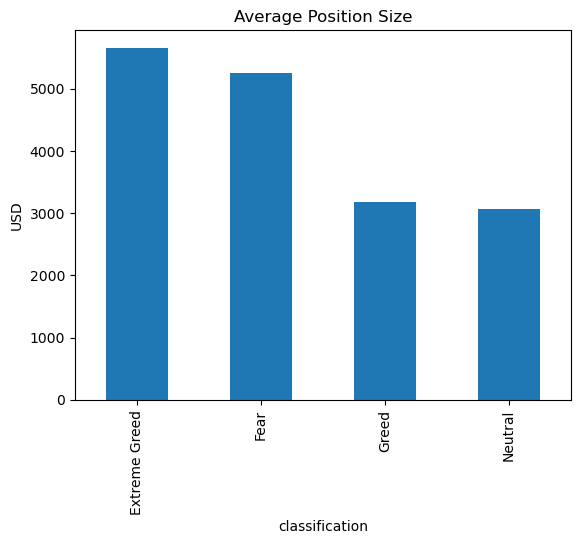

In [16]:
position = merged.groupby("classification")["Size USD"].mean()

print(position)

position.plot(kind="bar")

plt.title("Average Position Size")
plt.ylabel("USD")
plt.show()

### Observation

Traders used larger position sizes during Extreme Greed.

### Long vs Short Ratio

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


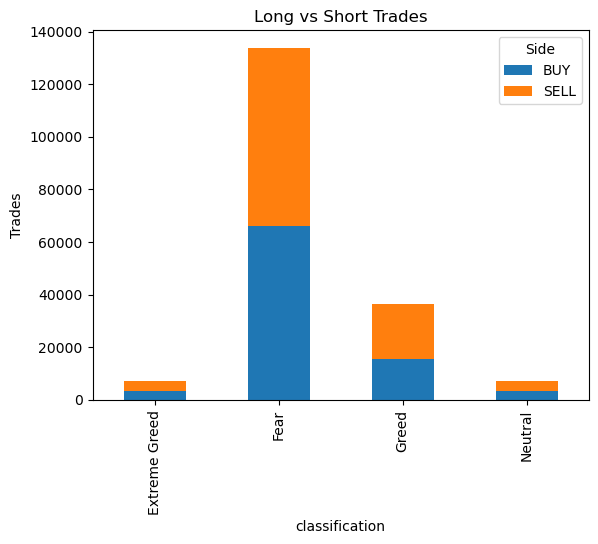

In [17]:
long_short = pd.crosstab(merged["classification"],merged["Side"])

print(long_short)

long_short.plot(kind="bar",stacked=True)

plt.title("Long vs Short Trades")
plt.ylabel("Trades")
plt.show()

### Observation

BUY trades slightly outnumbered SELL trades.

## Conclusion
Yes. Market sentiment influences trading frequency, position sizing, and buying/selling behavior.

## Question 3

Can traders be segmented based on their trading behavior and performance?

### Frequent vs Infrequent Traders

In [19]:
trade_count = merged.groupby("Account").size().reset_index(name="Trades")

median_trades = trade_count["Trades"].median()

trade_count["Segment"] = trade_count["Trades"].apply(
    lambda x:"Frequent Trader" if x>=median_trades else "Infrequent Trader"
)

print(trade_count.head())

                                      Account  Trades            Segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012    3818    Frequent Trader
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    7280    Frequent Trader
2  0x271b280974205ca63b716753467d5a371de622ab    3809    Frequent Trader
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   13311    Frequent Trader
4  0x2c229d22b100a7beb69122eed721cee9b24011dd    3239  Infrequent Trader


### Observation

Infrequent traders achieved higher average profits

#### The average Closed PnL of Frequent and Infrequent traders is compared to understand whether trading frequency impacts profitability.

Segment
Frequent Trader      42.493421
Infrequent Trader    96.943024
Name: Closed PnL, dtype: float64


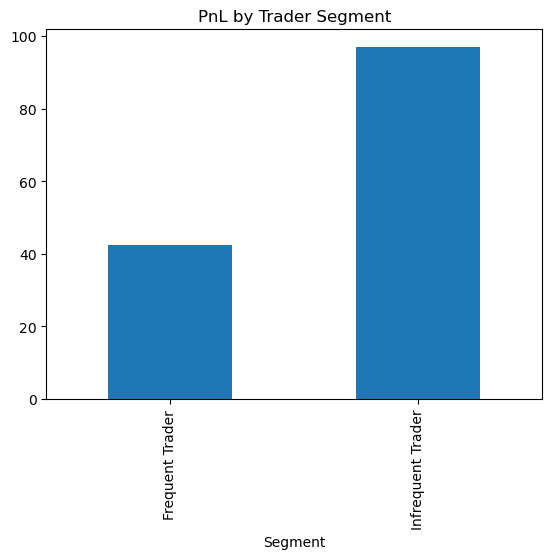

In [20]:
segment_pnl = merged.merge(trade_count[["Account","Segment"]],on="Account")

segment_result = segment_pnl.groupby("Segment")["Closed PnL"].mean()

print(segment_result)

segment_result.plot(kind="bar")

plt.title("PnL by Trader Segment")
plt.show()

### Consistent Winners vs Inconsistent Traders

In [21]:
win_summary = merged.groupby("Account")["Win"].mean()*100

winner_segment = pd.DataFrame(win_summary)

winner_segment.columns=["Win Rate"]

winner_segment["Segment"] = winner_segment["Win Rate"].apply(
    lambda x:"Consistent Winner" if x>=60 else "Inconsistent"
)

print(winner_segment.head())

                                             Win Rate       Segment
Account                                                            
0x083384f897ee0f19899168e3b1bec365f52a9012  35.961236  Inconsistent
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  44.271978  Inconsistent
0x271b280974205ca63b716753467d5a371de622ab  30.191651  Inconsistent
0x28736f43f1e871e6aa8b1148d38d4994275d72c4  43.858463  Inconsistent
0x2c229d22b100a7beb69122eed721cee9b24011dd  51.991355  Inconsistent


### Large Position vs Small Position Traders

In [22]:
avg_size = merged.groupby("Account")["Size USD"].mean()

size_segment = pd.DataFrame(avg_size)

median_size = size_segment["Size USD"].median()

size_segment["Segment"] = size_segment["Size USD"].apply(
    lambda x:"Large Position" if x>=median_size else "Small Position"
)

print(size_segment.head())

                                                Size USD         Segment
Account                                                                 
0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734  Large Position
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327  Small Position
0x271b280974205ca63b716753467d5a371de622ab   8893.000898  Large Position
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933  Small Position
0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782  Small Position


## Conclusion
Trader segmentation reveals meaningful behavioral differences. Infrequent traders showed better profitability, while position size and consistency varied across accounts.

### Bonus Analysis (Optional)
Distribution of Profit and Loss Across Market Sentiment

Objective:
To visualize how the distribution of Closed PnL varies across different market sentiment categories (Fear, Greed, Neutral, and Extreme Greed). Unlike average values, a box plot highlights the spread of profits, median performance, and the presence of unusually large gains or losses (outlier

<Figure size 800x500 with 0 Axes>

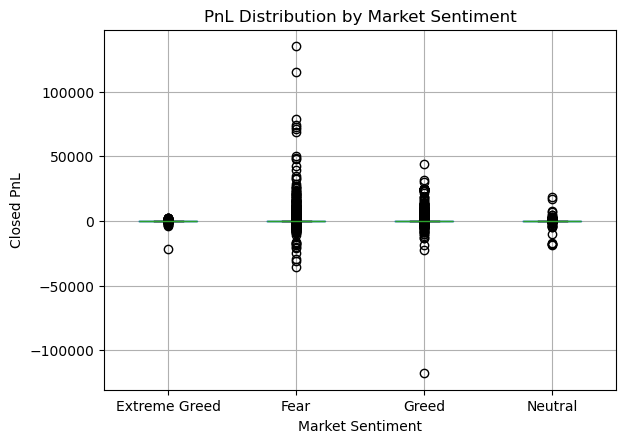

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
merged.boxplot(column="Closed PnL", by="classification")
plt.title("PnL Distribution by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

### Conclusion

The distribution suggests that market sentiment affects not only average profitability but also the consistency and risk associated with trading performance. Traders should therefore consider both expected returns and the variability of outcomes when making trading decisions.

## Part C – Actionable Strategy Recommendations
Strategy 1: Adjust Position Sizing During Fear Markets

The analysis suggests that trader performance was generally weaker during Fear market conditions. In such situations, using smaller position sizes and avoiding unnecessary risk may help reduce losses. Instead of trying to capture every market move, traders may benefit from waiting for stronger confirmation before entering new positions.

Strategy 2: Take Advantage of Stronger Market Conditions Carefully

The results indicate that Greed periods were associated with better average profitability and higher win rates. During these conditions, traders can consider increasing trading activity, but only while following proper risk management rules. Higher market confidence should not be treated as a reason to over-leverage or ignore stop-loss levels.

#### Practical Takeaway

Rather than following a single trading approach in all market conditions, traders can adapt their position sizing and trading activity based on market sentiment. Combining sentiment signals with disciplined risk management may improve overall trading consistency.

#### Final Conclusion

This project explored the relationship between Bitcoin market sentiment and trader performance using historical Hyperliquid trading data. After cleaning and combining both datasets, several trading metrics such as profit and loss, win rate, trading frequency, position size, and trader segments were analyzed.

The analysis showed noticeable differences in trader performance across different market sentiment conditions. In this dataset, Greed periods were generally associated with higher average profitability and better win rates, while Fear periods showed relatively lower performance. Trading behaviour also varied with sentiment, particularly in terms of trading activity and average position size.

To better understand trader behaviour, accounts were grouped into different segments, including frequent and infrequent traders as well as consistent and inconsistent performers. These segments highlighted that traders do not behave uniformly under different market conditions and that performance varies across groups.
Overall, the findings suggest that market sentiment can be a useful additional signal when making trading decisions. Although sentiment alone should not determine a trading strategy, combining it with proper risk management and trading discipline may help improve decision-making.